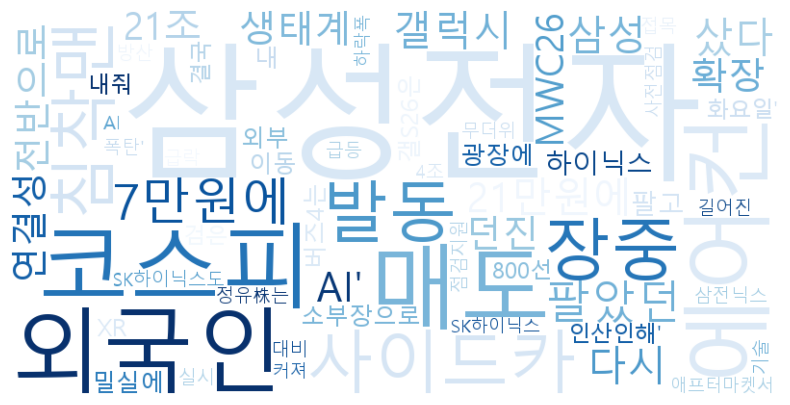

In [3]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. 어제 저장한 csv 파일 불러오기
df = pd.read_csv('../data/samsung_news.csv')

# 2. 표 안에 있는 제목들 띄어쓰기 기준으로 하나의 거대한 문장으로 합치기
text = " ".join(title for title in df['Title'].astype(str))

# 3. 윈도우용 '맑은고딕' 폰트 경로 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'

# 4. 워드클라우드 도화지 세팅 및 워드클라우드 생성
wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color='white',
    colormap='Blues'
).generate(text)

# 5. 화면에 예쁘게 출력하기
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [4]:
import pandas as pd
from transformers import pipeline

print("AI 설치중 (1회만 시간 걸림)")

# 1. 서울대학교의 한국어 금융 감성 분석 AI 모델 불러오기
# pipeline은 복잡한 딥러닝 과정을 아주 쉽게 한 줄로 쓸 수 있게 해주는 마법의 함수
analyzer = pipeline(
    "text-classification", 
    model="snunlp/KR-FinBert-SC"
)

# 2. 뉴스 데이터 불러오기
df = pd.read_csv('../data/samsung_news.csv')

# 3. AI에게 뉴스 제목들을 읽히고 긍정/부정/중립 판정받기
titles = df['Title'].tolist()
ai_results = analyzer(titles)

# 4. 분석 결과를 DataFrame에 새로운 열로 추가하기
df['감성_판단'] = [result['label'] for result in ai_results]
df['AI_확신도'] = [round(result['score'] * 100, 2) for result in ai_results]

# 5. 출력
print('\n--- AI가 분석한 삼성전자 뉴스 감성 결과 ---')
df.head(10)

c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AI 설치중 (1회만 시간 걸림)


c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sehol\.cache\huggingface\hub\models--snunlp--KR-FinBert-SC. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 980.34it/s, Materi


--- AI가 분석한 삼성전자 뉴스 감성 결과 ---


,Title,감성_판단,AI_확신도
0,삼성전자 장중 7%↓…코스피 매도 사이드카 발동,neutral,56.09
1,"침착맨 ""7만원에 팔았던 삼성전자, 21만원에 다시 샀다""",positive,65.78
2,"삼성, '갤럭시 AI' 생태계 전반으로 연결성 확장[MWC26]",positive,99.89
3,"21조 던진 외국인, 삼성전자·하이닉스 팔고 소부장으로 이동",neutral,99.14
4,"갤S26은 광장에, XR·버즈4는 밀실에…삼성전자 내·외부 '인산인해'",neutral,68.25
5,"'검은 화요일' 코스피, 결국 5,800선 내줘…삼성전자·SK하이닉스도 급락",negative,99.86
6,"외국인, 삼전닉스 4.4조 '매도 폭탄'… 방산·정유株는 급등",negative,99.90
7,"길어진 무더위 대비… 삼성전자, ‘AI 기술’ 접목 에어컨 점검지원",neutral,99.97
8,"삼성전자, 에어컨 사전점검 실시",positive,49.91
9,SK하이닉스 15.5%↓ 삼성전자 14.1%↓…애프터마켓서 하락폭 커져,negative,99.98
